<a href="https://colab.research.google.com/github/oriol-pomarol/codegeo_workshops/blob/lstm_workshop/10_time_series_with_lstm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

In [2]:
# Load the station data
station_names = ['cdp', 'oas', 'obs', 'ojp', 'rme', 'sap', 'snb', 'sod', 'swa', 'wfj']
station_data = {}
data_url = "https://raw.githubusercontent.com/oriol-pomarol/codegeo_workshops/lstm_workshop/datasets/snow_forecasting/"
for stn in station_names:
    filename = f"swe_met_insitu_{stn}.csv"
    station_data[stn] = pd.read_csv(data_url + filename, parse_dates=[0], index_col=0)

In [3]:
# Take the first 15 years as training and the last 5 as testing
rme_data = station_data['rme']
train_data = rme_data[rme_data.index < '2003-08-01']
test_data = rme_data[rme_data.index >= '2003-08-01']

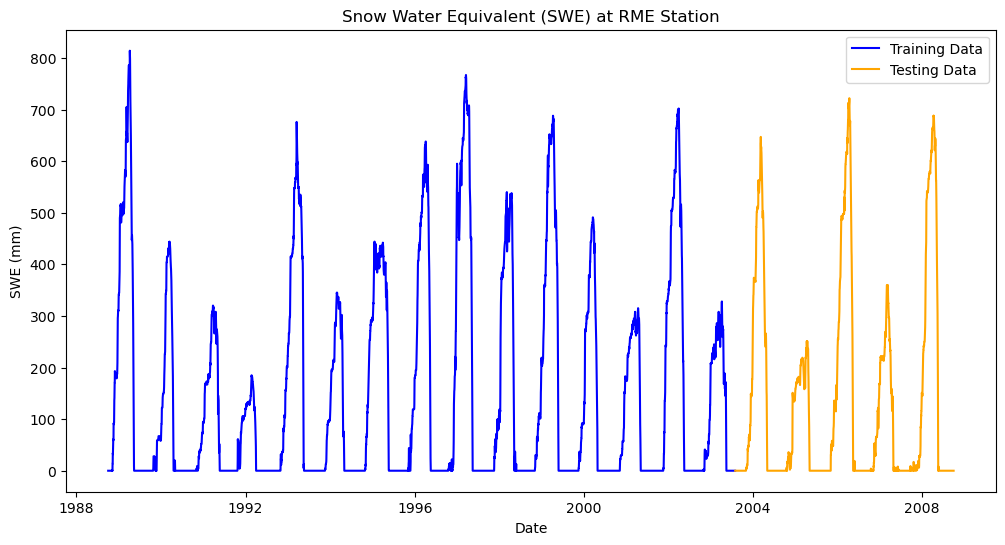

In [4]:
# Make a plot of the rme station
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['obs_swe'], label='Training Data', color='blue')
plt.plot(test_data.index, test_data['obs_swe'], label='Testing Data', color='orange')
plt.title('Snow Water Equivalent (SWE) at RME Station')
plt.xlabel('Date')
plt.ylabel('SWE (mm)')
plt.legend()
plt.show()

In [14]:
# Normalize the input features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_data.drop(columns=['obs_swe']))
X_test_scaled = scaler.transform(test_data.drop(columns=['obs_swe']))

In [15]:
# Define the number of time steps to look back
sequence_length = 14
n_features = X_train_scaled.shape[1]

# Define the LSTM model
model = tf.keras.models.Sequential()
model.add(tf.keras.Input(shape=(sequence_length, n_features)))
model.add(tf.keras.layers.LSTM(64, activation='relu'))
model.add(tf.keras.layers.Dense(1, activation='relu'))
model.compile(optimizer='adam', loss='mse')

In [16]:
# Create a time series dataset
train_dataset = tf.keras.preprocessing.timeseries_dataset_from_array(
    data=X_train_scaled,
    targets=train_data['obs_swe'].values,
    sequence_length=sequence_length,
    batch_size=32,
)

# Check the size of the dataset
for batch in train_dataset.take(1):
    inputs, targets = batch
    print(f'Input shape: {inputs.shape}, Target shape: {targets.shape}')

Input shape: (32, 14, 12), Target shape: (32,)


In [17]:
# Train the model
model.fit(train_dataset, epochs=20)

Epoch 1/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 48000.0898
Epoch 2/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 28082.9785
Epoch 3/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 23834.8750
Epoch 4/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 22728.6309
Epoch 5/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 22077.7988
Epoch 6/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 21373.9395
Epoch 7/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 20920.9336
Epoch 8/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 20495.3320
Epoch 9/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 20139.6758
Epoch 10/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 19816.6172
Epoch 11/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 19616.7500
Epoch 12/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 19273.9297
Epoch 13/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 19804.5098
Epoch 14/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 18712.3613
E

In [22]:
predictions = []
# Predict on test data
for seq_start in range(0, len(X_test_scaled) - sequence_length):
    seq_end = seq_start + sequence_length
    input_seq = X_test_scaled[seq_start:seq_end].reshape((1, sequence_length, n_features))
    prediction = model.predict(input_seq)
    predictions.append(prediction[0][0])
    # print(f'Predicted SWE for day {seq_end}: {prediction[0][0]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━

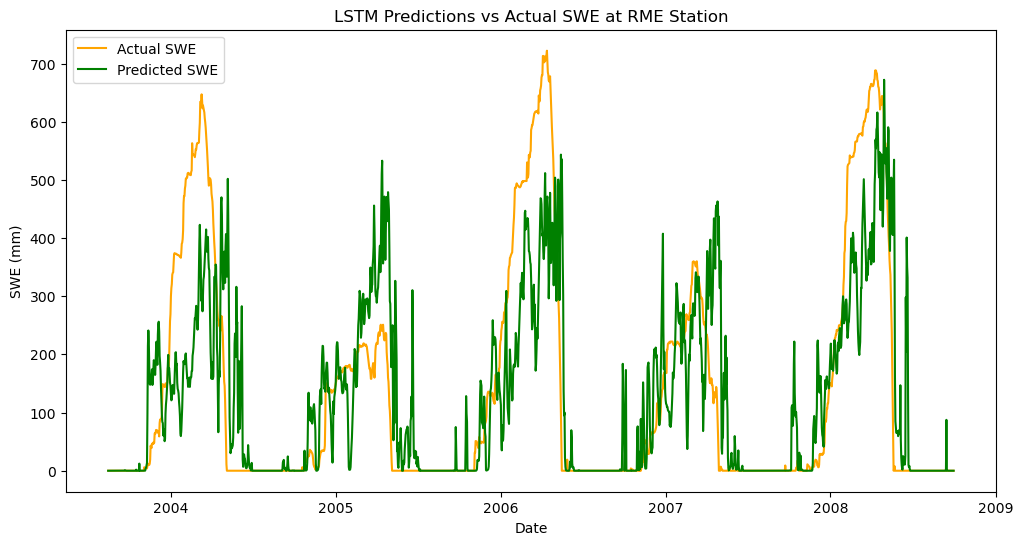

In [23]:
# Plot predictions vs actual
plt.figure(figsize=(12, 6))
plt.plot(test_data.index[sequence_length:], test_data['obs_swe'][sequence_length:], label='Actual SWE', color='orange')
plt.plot(test_data.index[sequence_length:], predictions, label='Predicted SWE', color='green')
plt.title('LSTM Predictions vs Actual SWE at RME Station')
plt.xlabel('Date')
plt.ylabel('SWE (mm)')
plt.legend()
plt.show()